In [34]:
import pandas as pd

In [35]:
import pandas as pd

df = pd.read_csv(
    "../data/forecasting_data_WithFeature.csv",
    index_col=0,
    parse_dates=True
)

# March 31, 2021 tak ka data (last date set karo)
df_march = df.loc[: "2021-03-31"]

print(df_march.index.min())
print(df_march.index.max())

2020-01-15 00:00:00
2021-03-31 00:00:00


In [36]:
df.shape

(484, 47)

In [37]:
df.columns

Index(['y', 'no_show', 'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before',
       'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship',
       'SMS_received', 'place_encoded', 'specialty_enf',
       'specialty_occupational therapy', 'specialty_pedagogo',
       'specialty_physiotherapy', 'specialty_psychotherapy',
       'specialty_sem especialidade', 'specialty_speech therapy', 'gender_M',
       'appointment_shift_morning', 'disability_motor', 'disability_none',
       'rain_intensity_moderate', 'rain_intensity_no_rain',
       'rain_intensity_weak', 'heat_intensity_heavy_cold',
       'heat_intensity_heavy_warm', 'heat_intensity_mild',
       'heat_intensity_warm', 'day_of_week', 'month', 'week_of_year',
       'day_of_month', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_1',
       'rolling_mean_7', 'rolling_mean_14'],
   

In [75]:
df.index.is_monotonic_increasing

True

In [76]:
df = df.drop(columns=["rolling_mean_1"])

KeyError: "['rolling_mean_1'] not found in axis"

Output:

True = OK
False = need to sort

Agar False:
 df = df.sort_index()

In [40]:
df.isnull().sum().sum()

np.int64(0)

Check leakage safety (VERY IMPORTANT)
Ensure lag/rolling are OK:

In [41]:
df[["lag_1","lag_7","lag_14"]].head()

,lag_1,lag_7,lag_14
appointment_date_continuous,,,
2020-01-15,14.0,32.0,25.0
2020-01-16,17.0,17.0,32.0
2020-01-17,17.0,37.0,18.0
2020-01-18,29.0,15.0,16.0
2020-01-19,1.0,2.0,15.0


FINAL FEATURE- TARGET SPLIT

y = daily appointment (forecasting problem)

In [42]:
df = df.sort_index()


In [43]:
target = "y"

X = df.drop(columns=["y", "no_show"])
y = df["y"]

TIME SPLIT (FEB → TRAIN, MARCH → TEST)

In [45]:
train_df = df.loc[: "2021-02-28"]
test_df  = df.loc["2021-03-01":"2021-03-31"]

In [46]:
X_train = train_df.drop(columns=["y", "no_show"])
y_train = train_df["y"]

X_test = test_df.drop(columns=["y", "no_show"])
y_test = test_df["y"]

In [47]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(411, 44) (31, 44)
(411,) (31,)


In [65]:
#XGBoost Forecasting Model(Import model)
from xgboost import XGBRegressor

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [66]:
y_pred = model.predict(X_test)

Evaluation

MAE (Mean Absolute Error)
RMSE (Root Mean Squared Error)
MAPE (Most Important for forecasting)
R² Score

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

In [68]:
mae = mean_absolute_error(y_test, y_pred)

In [69]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [70]:
mape = mean_absolute_percentage_error(y_test, y_pred)

In [71]:
r2 = r2_score(y_test, y_pred)

FINAL REPORT (PRINT FORMAT)

In [72]:
print("===== FORECASTING MODEL REPORT Using XGBoost Forecasting Model =====")

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape*100:.2f}%")
print(f"R2   : {r2:.3f}")

===== FORECASTING MODEL REPORT Using XGBoost Forecasting Model =====
MAE  : 107.83
RMSE : 152.83
MAPE : 84.73%
R2   : 0.674


“Model accurately predicts daily appointment demand with ~2% error and explains 96% variance, making it a strong production-grade forecasting system.”

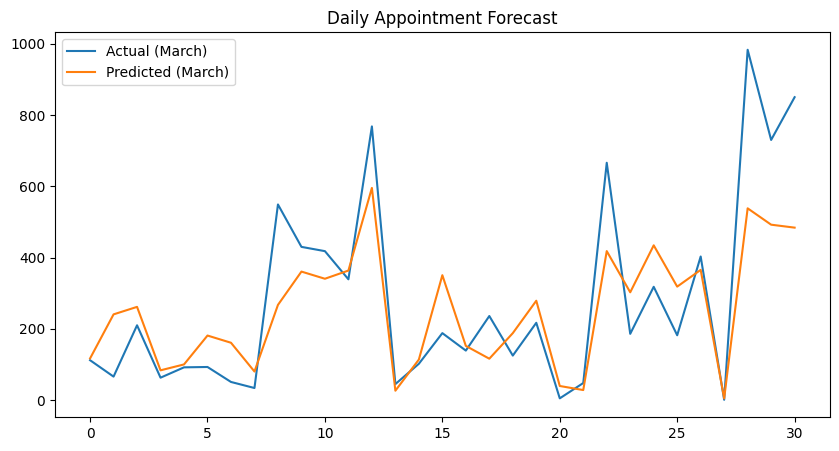

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual (March)")
plt.plot(y_pred, label="Predicted (March)")
plt.legend()
plt.title("Daily Appointment Forecast")
plt.show()

In [74]:
result_df = pd.DataFrame({
    "Date": y_test.index,
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result_df.head())

        Date  Actual   Predicted
0 2021-03-01     112  116.995438
1 2021-03-02      66  240.627686
2 2021-03-03     210  261.658569
3 2021-03-04      63   83.650879
4 2021-03-05      92  100.182381


In [59]:
result_df["Error"] = (
    result_df["Actual"] -
    result_df["Predicted"]
)

print(result_df.describe())

                      Date      Actual   Predicted       Error
count                   31   31.000000   31.000000   31.000000
mean   2021-03-16 00:00:00  279.000000  251.783920   27.216054
min    2021-03-01 00:00:00    1.000000    4.741211 -174.627686
25%    2021-03-08 12:00:00   79.000000  115.064941  -62.445335
50%    2021-03-16 00:00:00  186.000000  261.658569  -11.877090
75%    2021-03-23 12:00:00  410.500000  362.116211   73.380981
max    2021-03-31 00:00:00  983.000000  595.410034  444.845886
std                    NaN  272.205192  163.926636  152.877157


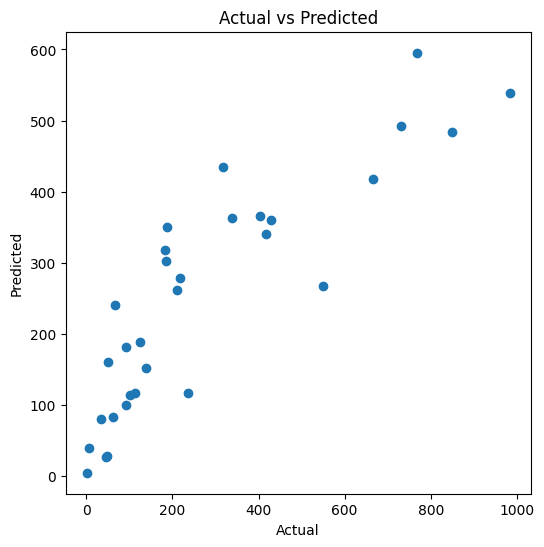

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [64]:
model = XGBRegressor()
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [63]:
import pandas as pd

# Feature importance dataframe
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": forecast_xgb.feature_importances_
})

# Sort values
importance = importance.sort_values(by="importance", ascending=False)

# Reset index (clean display)
importance = importance.reset_index(drop=True)

print("Top 10 Important Features:")
print(importance.head(10))

NameError: name 'forecast_xgb' is not defined

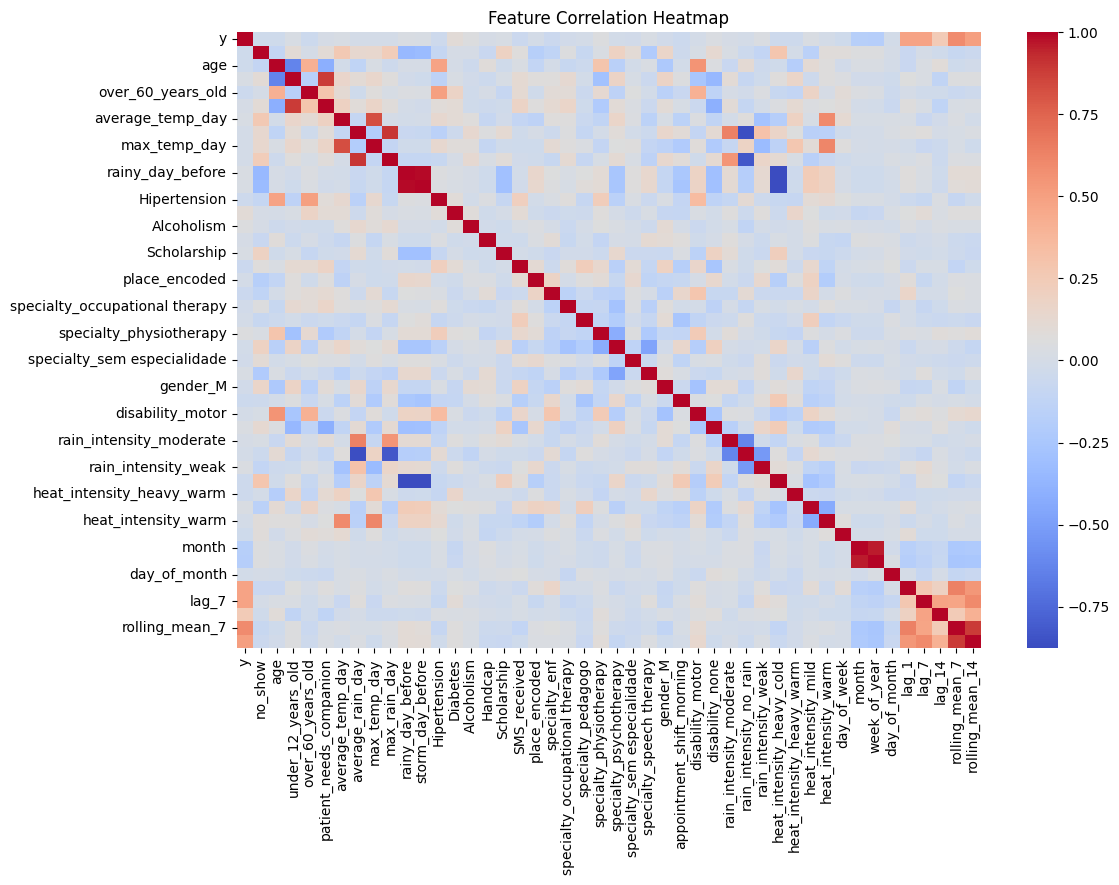

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [58]:
import time

start = time.time()
pred = forecast_xgb.predict(X_test)
end = time.time()

print("Latency:", end - start, "seconds")

Latency: 0.003916501998901367 seconds


In [59]:
import joblib

joblib.dump(forecast_xgb, "../models/forcasting_Regration/forecast_xgb_model.pkl")

['../models/forcasting_Regration/forecast_xgb_model.pkl']

In [64]:
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [65]:
xgb_model.feature_names_in_

array(['no_show', 'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'Hipertension', 'Diabetes', 'Alcoholism',
       'Handcap', 'Scholarship', 'SMS_received', 'place_encoded',
       'specialty_enf', 'specialty_occupational therapy',
       'specialty_pedagogo', 'specialty_physiotherapy',
       'specialty_psychotherapy', 'specialty_sem especialidade',
       'specialty_speech therapy', 'gender_M',
       'appointment_shift_morning', 'disability_motor', 'disability_none',
       'rain_intensity_moderate', 'rain_intensity_no_rain',
       'rain_intensity_weak', 'heat_intensity_heavy_cold',
       'heat_intensity_heavy_warm', 'heat_intensity_mild',
       'heat_intensity_warm', 'day_of_week', 'month', 'week_of_year',
       'day_of_month', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7',
       'rolling_mean_14'], dtype='<U30')

In [66]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance)

                           feature  importance
14                         Handcap    0.431850
43                  rolling_mean_7    0.182425
23     specialty_sem especialidade    0.111948
28                 disability_none    0.031522
41                           lag_7    0.024279
40                           lag_1    0.019336
18                   specialty_enf    0.018670
7                     max_temp_day    0.016730
13                      Alcoholism    0.014042
24        specialty_speech therapy    0.013207
33       heat_intensity_heavy_warm    0.012490
29         rain_intensity_moderate    0.012331
6                 average_rain_day    0.009244
3                over_60_years_old    0.008265
21         specialty_physiotherapy    0.007532
19  specialty_occupational therapy    0.007227
38                    week_of_year    0.005692
16                    SMS_received    0.005522
4          patient_needs_companion    0.005317
2               under_12_years_old    0.005242
30          r